# Introducción al clustering

In [120]:
import warnings
warnings.filterwarnings('ignore')

In [121]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import single, cophenet
from scipy.spatial.distance import pdist, squareform

In [122]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


# Importación de un modelo con datos de tarjetas de crédito (cc general.csv).

In [123]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt



path_filename = "CC_GENERAL.csv"
path_file =  os.path.join('', path_filename)

df = pd.read_csv(path_file, sep=',')


### Exploratory data analysis

In [124]:
df.sample()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5652,C15810,95.16,1.00,1000.00,0.00,1000.00,0.00,0.75,0.00,0.62,0.00,0,8,11500.00,824.87,101.68,0.80,8


In [125]:
df.shape

(8950, 18)

In [126]:
df.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [128]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.00,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,8950.00,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,8950.00,1003.20,2136.63,0.00,39.63,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.00,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.00,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.00,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,8950.00,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,8950.00,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.00,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,8950.00,0.14,0.20,0.00,0.00,0.00,0.22,1.50


In [129]:
df[df==0].count() / df.count()

CUST_ID                            0.00
BALANCE                            0.01
BALANCE_FREQUENCY                  0.01
PURCHASES                          0.23
ONEOFF_PURCHASES                   0.48
INSTALLMENTS_PURCHASES             0.44
CASH_ADVANCE                       0.52
PURCHASES_FREQUENCY                0.23
ONEOFF_PURCHASES_FREQUENCY         0.48
PURCHASES_INSTALLMENTS_FREQUENCY   0.44
CASH_ADVANCE_FREQUENCY             0.52
CASH_ADVANCE_TRX                   0.52
PURCHASES_TRX                      0.23
CREDIT_LIMIT                       0.00
PAYMENTS                           0.03
MINIMUM_PAYMENTS                   0.00
PRC_FULL_PAYMENT                   0.66
TENURE                             0.00
dtype: float64

In [130]:
df.head(4)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12
1,C10002,3202.47,0.91,0.00,0.00,0.00,6442.95,0.00,0.00,0.00,0.25,4,0,7000.00,4103.03,1072.34,0.22,12
2,C10003,2495.15,1.00,773.17,773.17,0.00,0.00,1.00,1.00,0.00,0.00,0,12,7500.00,622.07,627.28,0.00,12
3,C10004,1666.67,0.64,1499.00,1499.00,0.00,205.79,0.08,0.08,0.00,0.08,1,1,7500.00,0.00,NaN,0.00,12


In [131]:
df.nunique()

CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64

In [132]:
print('Existen',df.isnull().sum().sum(),'valores no definidos')

Existen 314 valores no definidos


In [133]:
print(df.columns[df.isnull().any()])

Index(['CREDIT_LIMIT', 'MINIMUM_PAYMENTS'], dtype='object')


In [134]:
df[df.columns[df.isnull().any()]].isnull().sum()

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

In [135]:
df[df.columns[df.isnull().any()]].isnull().sum()*100/df.shape[0]

CREDIT_LIMIT       0.01
MINIMUM_PAYMENTS   3.50
dtype: float64

In [136]:
print('Duplicate records:')
print(df[df.duplicated()])

Duplicate records:
Empty DataFrame
Columns: [CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY, CASH_ADVANCE_TRX, PURCHASES_TRX, CREDIT_LIMIT, PAYMENTS, MINIMUM_PAYMENTS, PRC_FULL_PAYMENT, TENURE]
Index: []


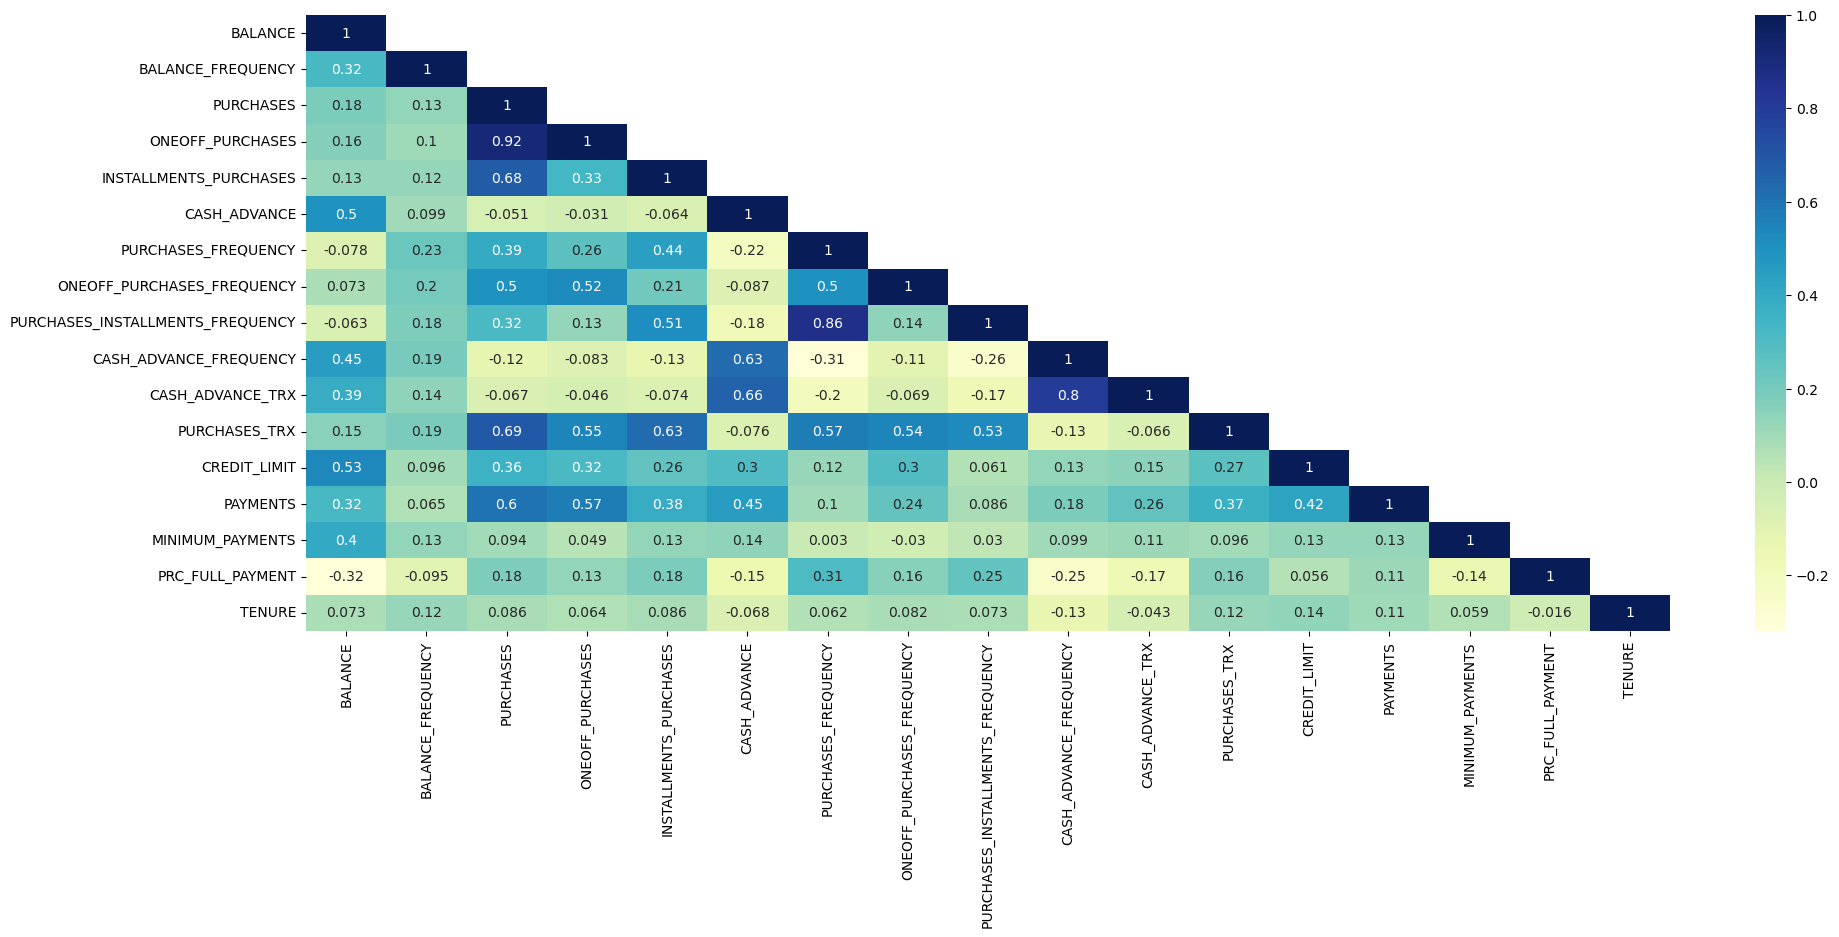

In [137]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

In [138]:
pd.options.display.float_format = '{:.2f}'.format

In [139]:
numerics = ['int16', 'int32','int64','float64']
df.select_dtypes(include=numerics).sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7622,685.06,1.00,0.00,0.00,0.00,110.80,0.00,0.00,0.00,0.25,4,0,700.00,308.04,334.27,0.00,12
7301,28.61,1.00,208.00,0.00,208.00,0.00,0.83,0.00,0.83,0.00,0,10,3000.00,253.54,169.80,0.00,12
7901,3178.01,0.88,0.00,0.00,0.00,4754.93,0.00,0.00,0.00,0.50,10,0,5000.00,522.53,646.38,0.00,8
789,1783.00,0.91,0.00,0.00,0.00,16037.33,0.00,0.00,0.00,0.42,11,0,10000.00,15923.29,517.60,0.00,12
2549,93.96,1.00,815.34,149.04,666.30,0.00,0.92,0.25,0.75,0.00,0,14,2500.00,361.79,125.69,0.30,12


In [140]:
cols_num = df.columns[[np.issubdtype(dt,np.number) for dt in df.dtypes]]

In [141]:
print(cols_num)
print(len(cols_num))

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')
17


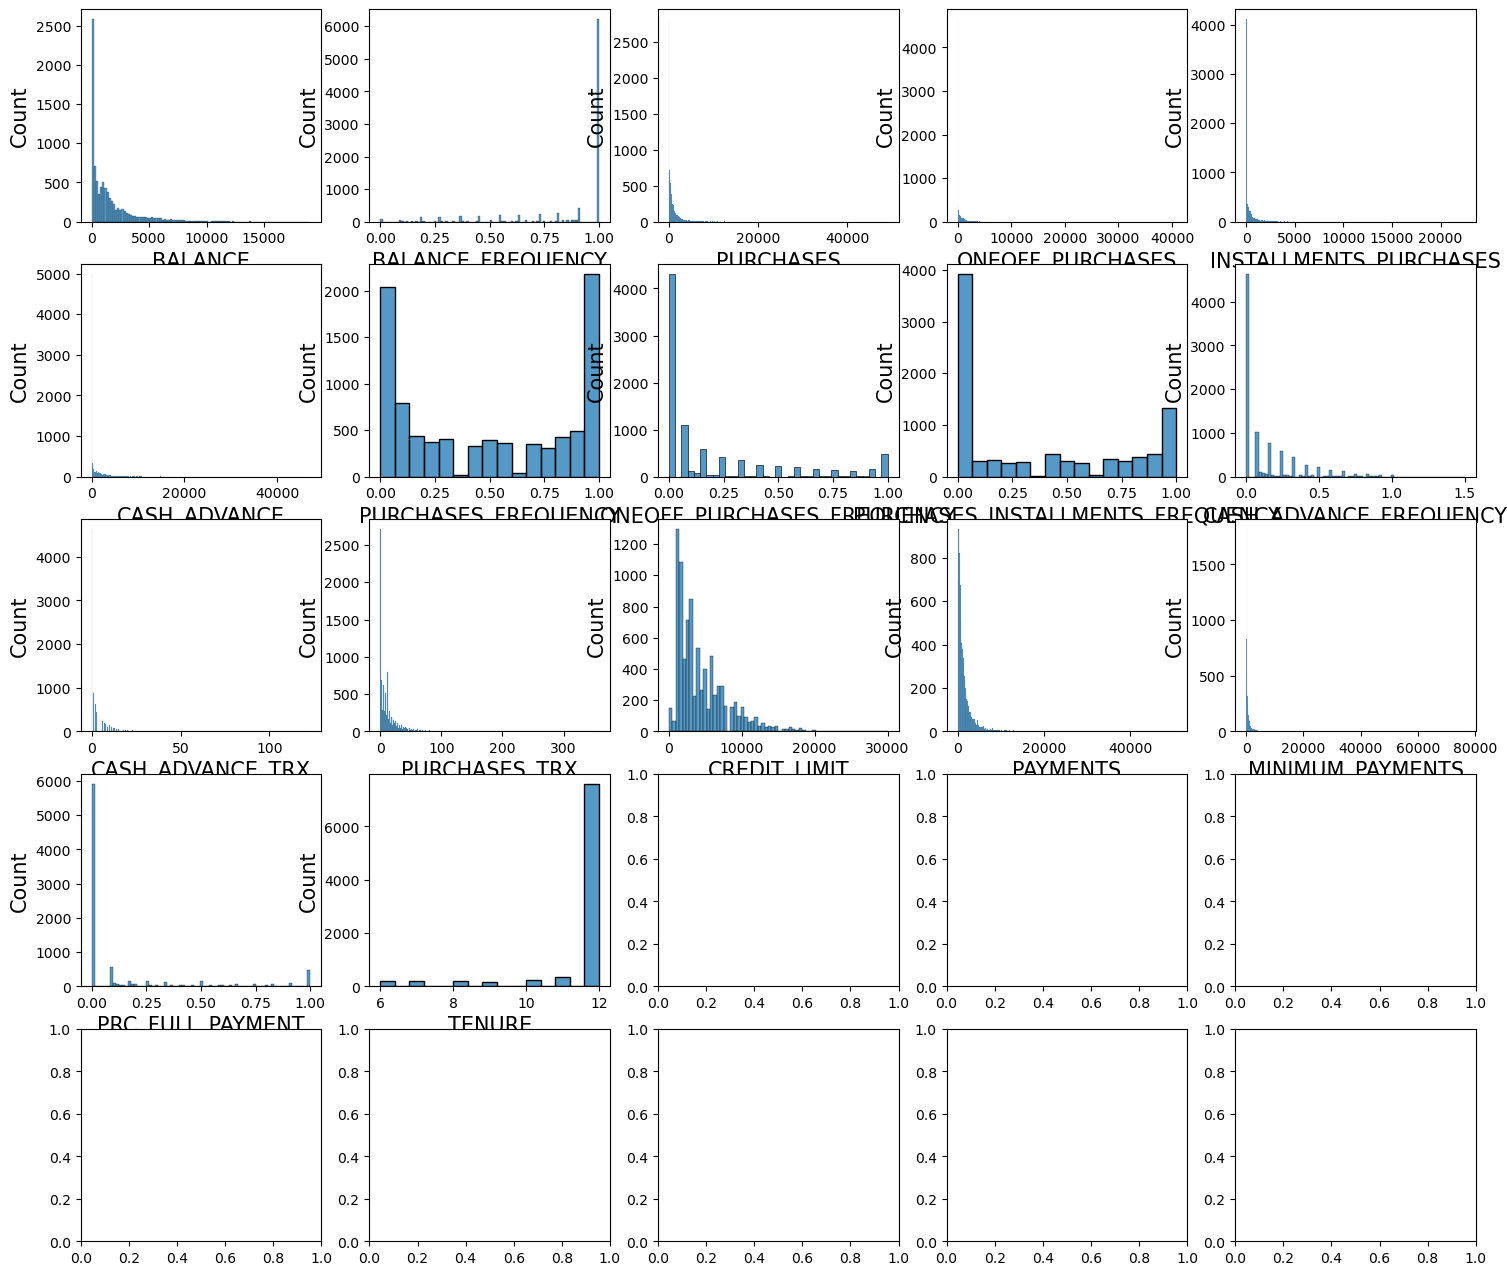

In [142]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

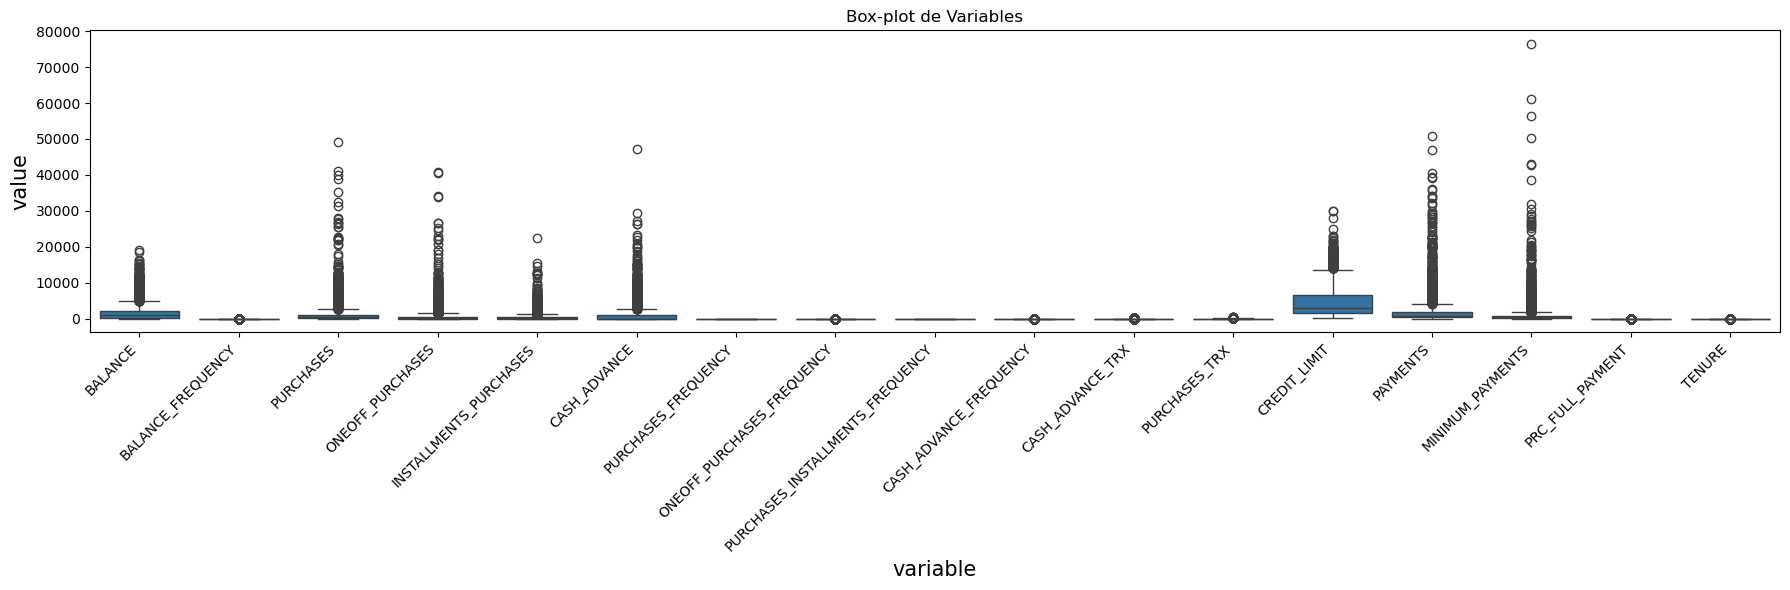

In [143]:
plt.figure(figsize=(18,6))
sns.boxplot(x='variable',y='value',data=pd.melt(df[cols_num])).set_title('Box-plot de Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [144]:
df2 = df.copy()
df2.head(1)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12


In [145]:
df3 = df.copy()
df3.head(1)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.90,0.82,95.40,0.00,95.40,0.00,0.17,0.00,0.08,0.00,0,2,1000.00,201.80,139.51,0.00,12


In [146]:
from scipy.stats import pearsonr

def reg_coef(x,y, label=None, color= None,**kwargs):
    ax = plt.gca()
    r,p = pearsonr(x,y)
    ax.annotate('r={:.2}'.format(r),xy=(0.5,0.5),xycoords='axes fraction',ha='center',fontsize=15)
    ax.set_axis_off()

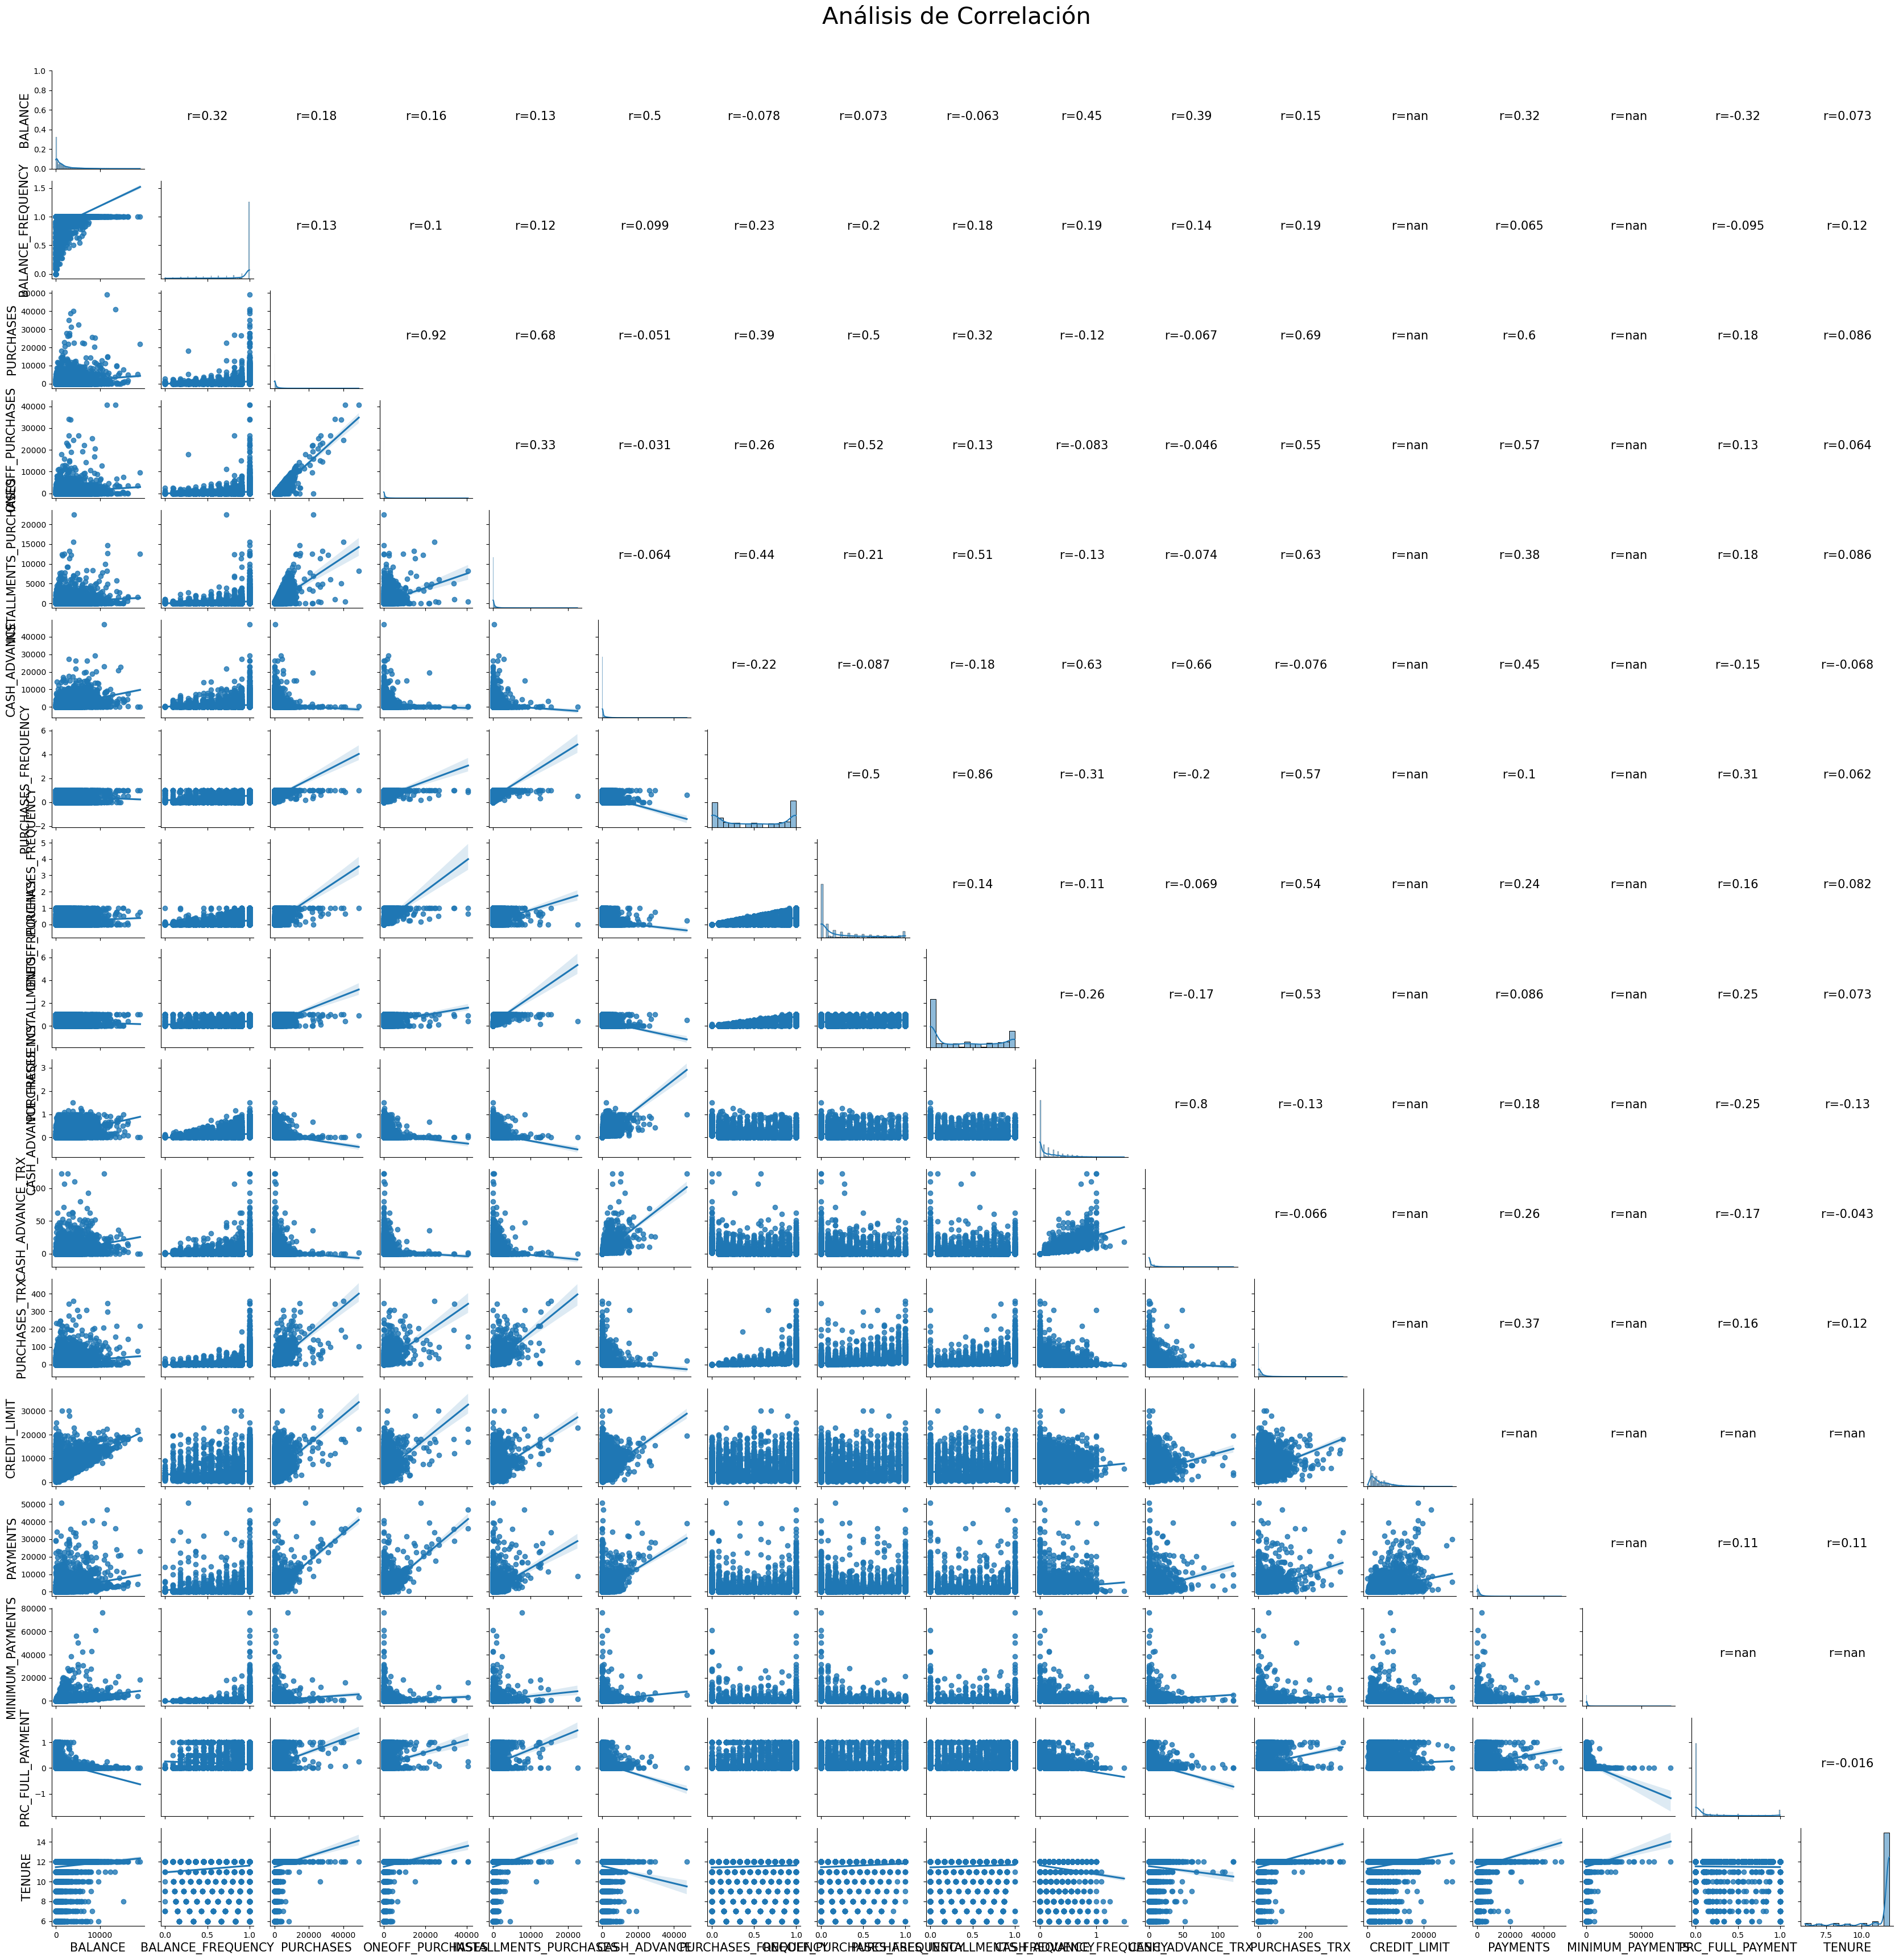

In [147]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

mpl.rcParams['axes.labelsize'] = 15

g = sns.PairGrid(df2, height=2)

g.map_diag(sns.histplot, kde=True)
g.map_lower(sns.regplot)
g.map_upper(reg_coef, fontsize=20, cmap=plt.get_cmap('GnBu'))

g.fig.suptitle('Análisis de Correlación', fontsize=30, y=1.02)

plt.show()

In [148]:
df2.dtypes

CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [149]:
from scipy.stats import zscore
df2 = df2[cols_num].apply(zscore)

In [150]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.00,-0.00,1.00,-0.75,-0.69,-0.33,0.24,8.40
BALANCE_FREQUENCY,8950.00,0.00,1.00,-3.70,0.05,0.52,0.52,0.52
PURCHASES,8950.00,0.00,1.00,-0.47,-0.45,-0.30,0.05,22.48
ONEOFF_PURCHASES,8950.00,-0.00,1.00,-0.36,-0.36,-0.33,-0.01,24.20
INSTALLMENTS_PURCHASES,8950.00,0.00,1.00,-0.45,-0.45,-0.36,0.06,24.43
CASH_ADVANCE,8950.00,-0.00,1.00,-0.47,-0.47,-0.47,0.06,22.01
PURCHASES_FREQUENCY,8950.00,0.00,1.00,-1.22,-1.01,0.02,1.06,1.27
ONEOFF_PURCHASES_FREQUENCY,8950.00,0.00,1.00,-0.68,-0.68,-0.40,0.33,2.67
PURCHASES_INSTALLMENTS_FREQUENCY,8950.00,0.00,1.00,-0.92,-0.92,-0.50,0.97,1.60
CASH_ADVANCE_FREQUENCY,8950.00,-0.00,1.00,-0.68,-0.68,-0.68,0.44,6.82


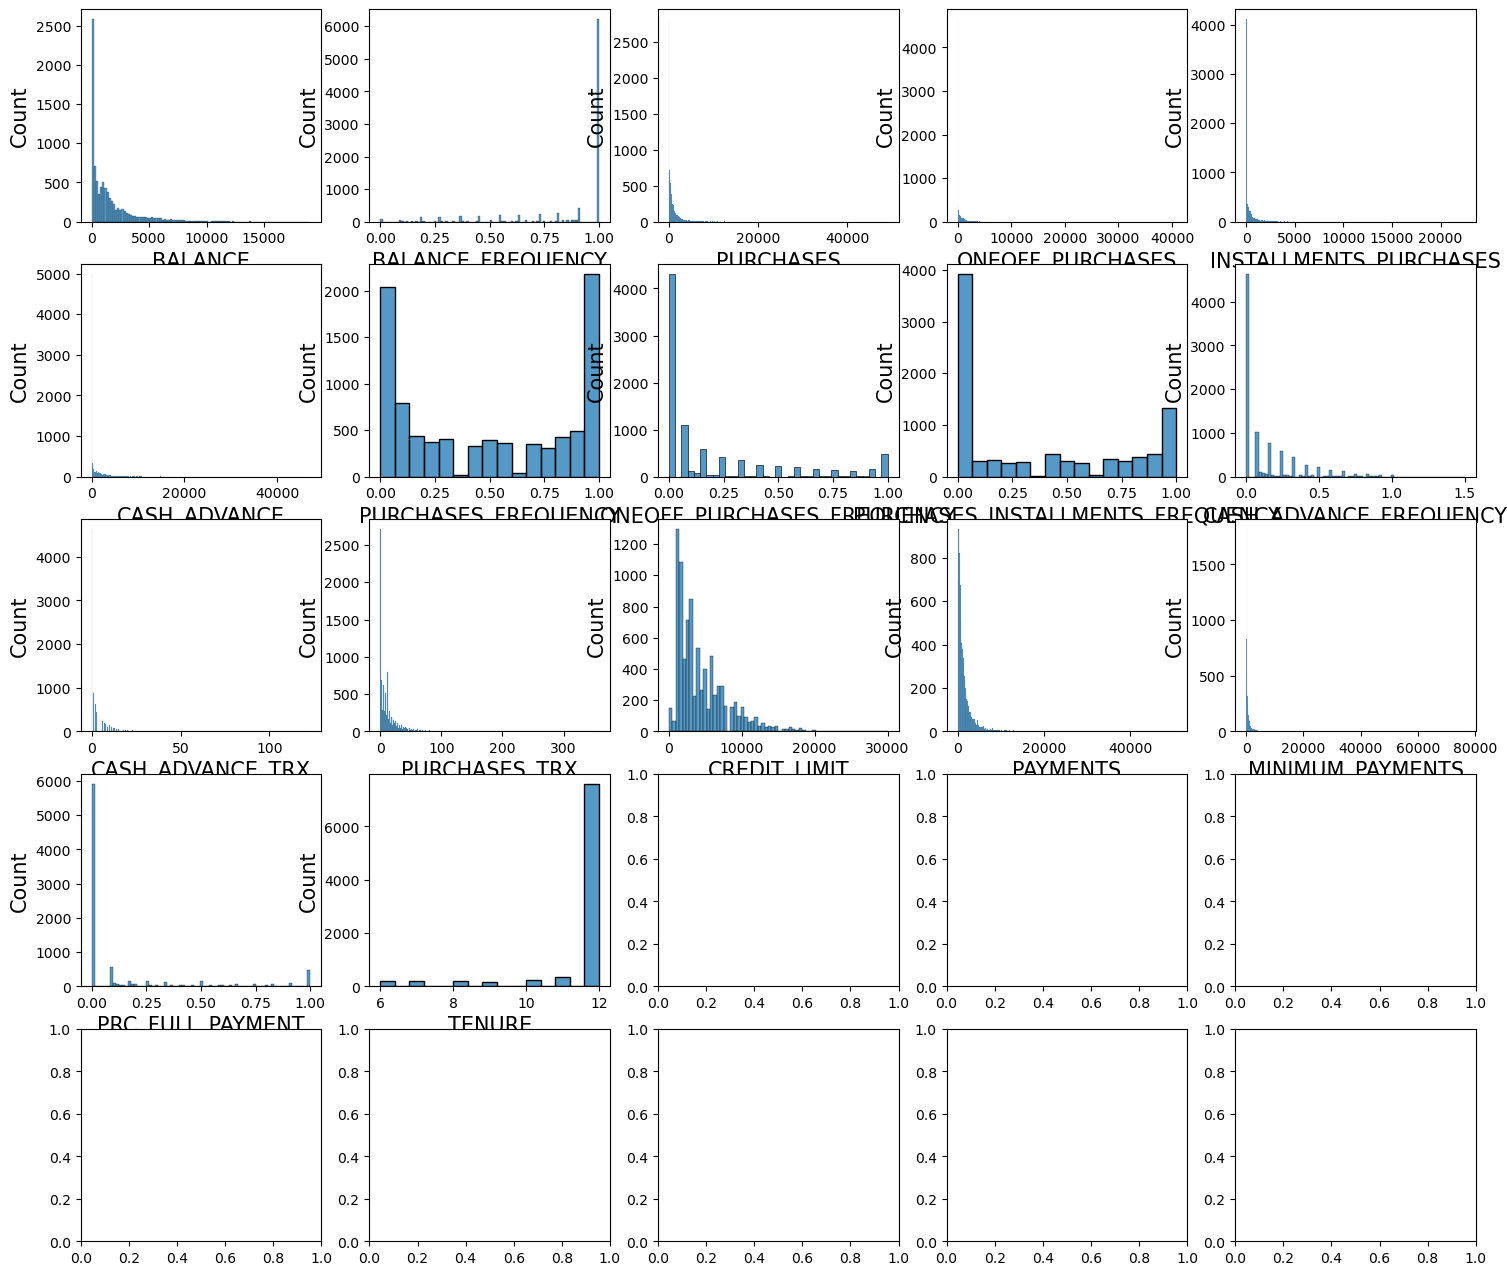

In [151]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(18,16))
for i, column in enumerate(cols_num):
    sns.histplot(df[column],ax=axes[i//5,i%5],kde=False)

# Modelo de Clustering K-Means

In [152]:
df2.sample()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
427,0.04,0.52,-0.47,-0.36,-0.45,-0.45,-1.22,-0.68,-0.92,-0.22,-0.18,-0.59,NaN,-0.48,NaN,-0.53,-0.39


In [153]:
df2.dtypes

BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                    float64
PURCHASES_TRX                       float64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                              float64
dtype: object

In [154]:
#df2=df2.drop('CUST_ID')

In [155]:
df2[df2.columns[df2.isnull().any()]].isnull().sum()

CREDIT_LIMIT        8950
MINIMUM_PAYMENTS    8950
dtype: int64

In [156]:
df2.head(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.73,-0.25,-0.42,-0.36,-0.35,-0.47,-0.81,-0.68,-0.71,-0.68,-0.48,-0.51,NaN,-0.53,NaN,-0.53,0.36
1,0.79,0.13,-0.47,-0.36,-0.45,2.61,-1.22,-0.68,-0.92,0.57,0.11,-0.59,NaN,0.82,NaN,0.23,0.36


In [157]:
df2 = df2.drop(['MINIMUM_PAYMENTS'],axis=1)

In [158]:
df2.sample(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
3673,-0.71,0.52,-0.36,-0.36,-0.20,-0.47,0.85,-0.68,1.18,-0.68,-0.48,-0.19,NaN,-0.50,-0.53,0.36
928,2.13,0.52,-0.47,-0.36,-0.45,0.09,-1.22,-0.68,-0.92,1.82,0.99,-0.59,NaN,-0.08,-0.53,0.36


In [159]:
df2[df2.columns[df2.isnull().any()]].isnull().sum()

CREDIT_LIMIT    8950
dtype: int64

In [160]:
df2 = df2.drop(['CREDIT_LIMIT'],axis=1)

In [161]:
df2.sample(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
5417,-0.74,-3.28,-0.47,-0.36,-0.45,-0.24,-1.22,-0.68,-0.92,-0.18,-0.33,-0.59,-0.60,-0.53,-1.13
2619,-0.18,0.52,-0.47,-0.36,-0.45,-0.34,-1.22,-0.68,-0.92,2.24,0.70,-0.59,-0.42,-0.53,0.36


In [162]:
df2[df2.columns[df2.isnull().any()]].isnull().sum()

Series([], dtype: float64)

In [163]:
#df2.dropna()

In [164]:
df2.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
395,0.45,0.52,-0.47,-0.36,-0.45,0.66,-1.22,-0.68,-0.92,-0.26,-0.18,-0.59,-0.41,-0.53,0.36
7216,0.14,0.52,0.00,-0.01,0.03,0.13,0.02,-0.40,-0.08,-0.26,0.26,0.01,-0.37,-0.53,0.36
3878,-0.35,0.52,3.46,3.75,1.30,-0.47,1.27,2.67,1.60,-0.68,-0.48,4.16,2.19,2.89,0.36
3108,-0.04,0.52,-0.18,-0.17,-0.12,-0.47,0.44,0.44,-0.08,-0.68,-0.48,0.01,-0.40,-0.53,0.36
6019,-0.51,0.13,0.30,-0.02,0.75,0.46,0.23,0.16,0.34,0.16,-0.18,-0.07,0.69,0.10,0.36


In [165]:
df2.shape

(8950, 15)

Text(0.5, 1.0, 'Resultados KMeans')

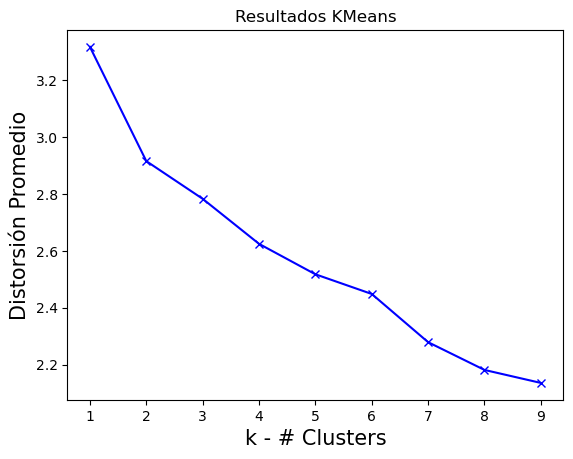

In [166]:
from scipy.spatial.distance import cdist
clusters = range(1,10)
meanDistortions = []


for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(df2)
    prediction = model.predict(df2)
    meanDistortions.append(sum(np.min(cdist(df2,model.cluster_centers_,'euclidean'),axis=1))/df2.shape[0])

plt.plot(clusters,meanDistortions,'bx-')
plt.xlabel('k - # Clusters')
plt.ylabel('Distorsión Promedio')
plt.title('Resultados KMeans')


In [167]:
prediction

array([2, 4, 3, ..., 1, 2, 3], dtype=int32)

### version 7 clusters

In [168]:
kmeans =  KMeans(n_clusters=7, n_init = 15, random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=7, n_init=15, random_state=1)

In [169]:
prediction

array([2, 4, 3, ..., 1, 2, 3], dtype=int32)

In [170]:
kmeans = KMeans(n_clusters=7,n_init=15,random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=7, n_init=15, random_state=1)

In [171]:
centroids = kmeans.cluster_centers_
centroids

array([[-3.25642010e-01, -3.50724688e-01, -2.87718634e-01,
        -2.11325407e-01, -2.91700206e-01,  8.69668123e-02,
        -2.08699584e-01, -2.77456331e-01, -2.37163531e-01,
         3.02488971e-01, -7.06154724e-03, -3.89806496e-01,
        -3.79728197e-01,  3.23057614e-03, -3.20656420e+00],
       [-3.44879429e-01,  3.31462434e-01, -3.57603664e-02,
        -2.35576124e-01,  3.48047263e-01, -3.68109640e-01,
         9.75628750e-01, -3.55228155e-01,  1.16851055e+00,
        -4.78298433e-01, -3.64124831e-01,  1.71573952e-01,
        -2.15869547e-01,  3.10974688e-01,  2.55059877e-01],
       [ 1.53974948e+00,  3.91566934e-01, -2.01102893e-01,
        -1.43865454e-01, -2.11269555e-01,  2.08290937e+00,
        -4.42396308e-01, -1.70224086e-01, -3.93401594e-01,
         2.08018878e+00,  2.12190477e+00, -2.26966552e-01,
         8.62357793e-01, -3.81684823e-01,  6.26943398e-02],
       [ 1.24746495e-01,  4.33163276e-01,  9.58611525e-01,
         9.18120132e-01,  5.79874915e-01, -3.04734592

In [172]:
centroid_df = pd.DataFrame(centroids,columns=list(df2))
centroid_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.33,-0.35,-0.29,-0.21,-0.29,0.09,-0.21,-0.28,-0.24,0.30,-0.01,-0.39,-0.38,0.00,-3.21
1,-0.34,0.33,-0.04,-0.24,0.35,-0.37,0.98,-0.36,1.17,-0.48,-0.36,0.17,-0.22,0.31,0.26
2,1.54,0.39,-0.20,-0.14,-0.21,2.08,-0.44,-0.17,-0.39,2.08,2.12,-0.23,0.86,-0.38,0.06
3,0.12,0.43,0.96,0.92,0.58,-0.30,1.10,1.91,0.53,-0.40,-0.31,1.22,0.39,0.44,0.29
4,1.40,0.41,7.21,6.40,5.30,0.02,1.08,1.91,1.02,-0.29,-0.10,4.83,4.98,0.84,0.33
5,-0.70,-2.13,-0.31,-0.23,-0.31,-0.32,-0.55,-0.43,-0.44,-0.52,-0.38,-0.42,-0.19,0.30,0.20
6,0.08,0.41,-0.34,-0.22,-0.40,-0.08,-0.81,-0.34,-0.75,0.09,-0.04,-0.47,-0.23,-0.46,0.27


In [173]:
df_labels = pd.DataFrame(kmeans.labels_,columns=list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [174]:
df_labeled = df2.join(df_labels)

In [175]:
df_labeled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'labels'],
      dtype='object')

In [176]:
df_labeled.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE,labels
0,-0.73,-0.25,-0.42,-0.36,-0.35,-0.47,-0.81,-0.68,-0.71,-0.68,-0.48,-0.51,-0.53,-0.53,0.36,6
1,0.79,0.13,-0.47,-0.36,-0.45,2.61,-1.22,-0.68,-0.92,0.57,0.11,-0.59,0.82,0.23,0.36,2
2,0.45,0.52,-0.11,0.11,-0.45,-0.47,1.27,2.67,-0.92,-0.68,-0.48,-0.11,-0.38,-0.53,0.36,3
3,0.05,-1.02,0.23,0.55,-0.45,-0.37,-1.01,-0.40,-0.92,-0.26,-0.33,-0.55,-0.60,-0.53,0.36,6
4,-0.36,0.52,-0.46,-0.35,-0.45,-0.47,-1.01,-0.40,-0.92,-0.68,-0.48,-0.55,-0.36,-0.53,0.36,6
5,0.12,0.52,0.15,-0.36,1.02,-0.47,0.44,-0.68,0.55,-0.68,-0.48,-0.27,-0.12,-0.53,0.36,1
6,-0.45,0.52,2.85,3.50,0.31,-0.47,1.27,2.67,1.60,-0.68,-0.48,1.98,1.60,2.89,0.36,3
7,0.12,0.52,-0.27,-0.36,0.03,-0.47,1.27,-0.68,1.60,-0.68,-0.48,-0.11,-0.36,-0.53,0.36,1
8,-0.26,0.52,-0.07,0.04,-0.23,-0.47,-0.39,-0.40,-0.29,-0.68,-0.48,-0.39,-0.36,-0.53,0.36,6
9,-0.68,-1.40,0.13,0.42,-0.45,-0.47,-0.81,-0.12,-0.92,-0.68,-0.48,-0.47,-0.20,-0.53,0.36,5


In [177]:
df_labeled['labels'].value_counts()

labels
6    2888
1    2080
3    1258
5    1197
2     819
0     629
4      79
Name: count, dtype: int64

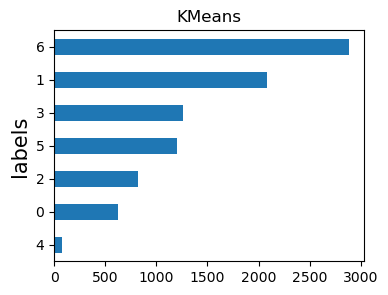

In [178]:
fig, ax = plt.subplots(figsize=(4,3))

pd.value_counts(df_labeled['labels']) \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('KMeans')
plt.show()

In [179]:
df2.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

Text(0.5, 0.98, 'Configuración de Clusters por Variable (KMeans)')

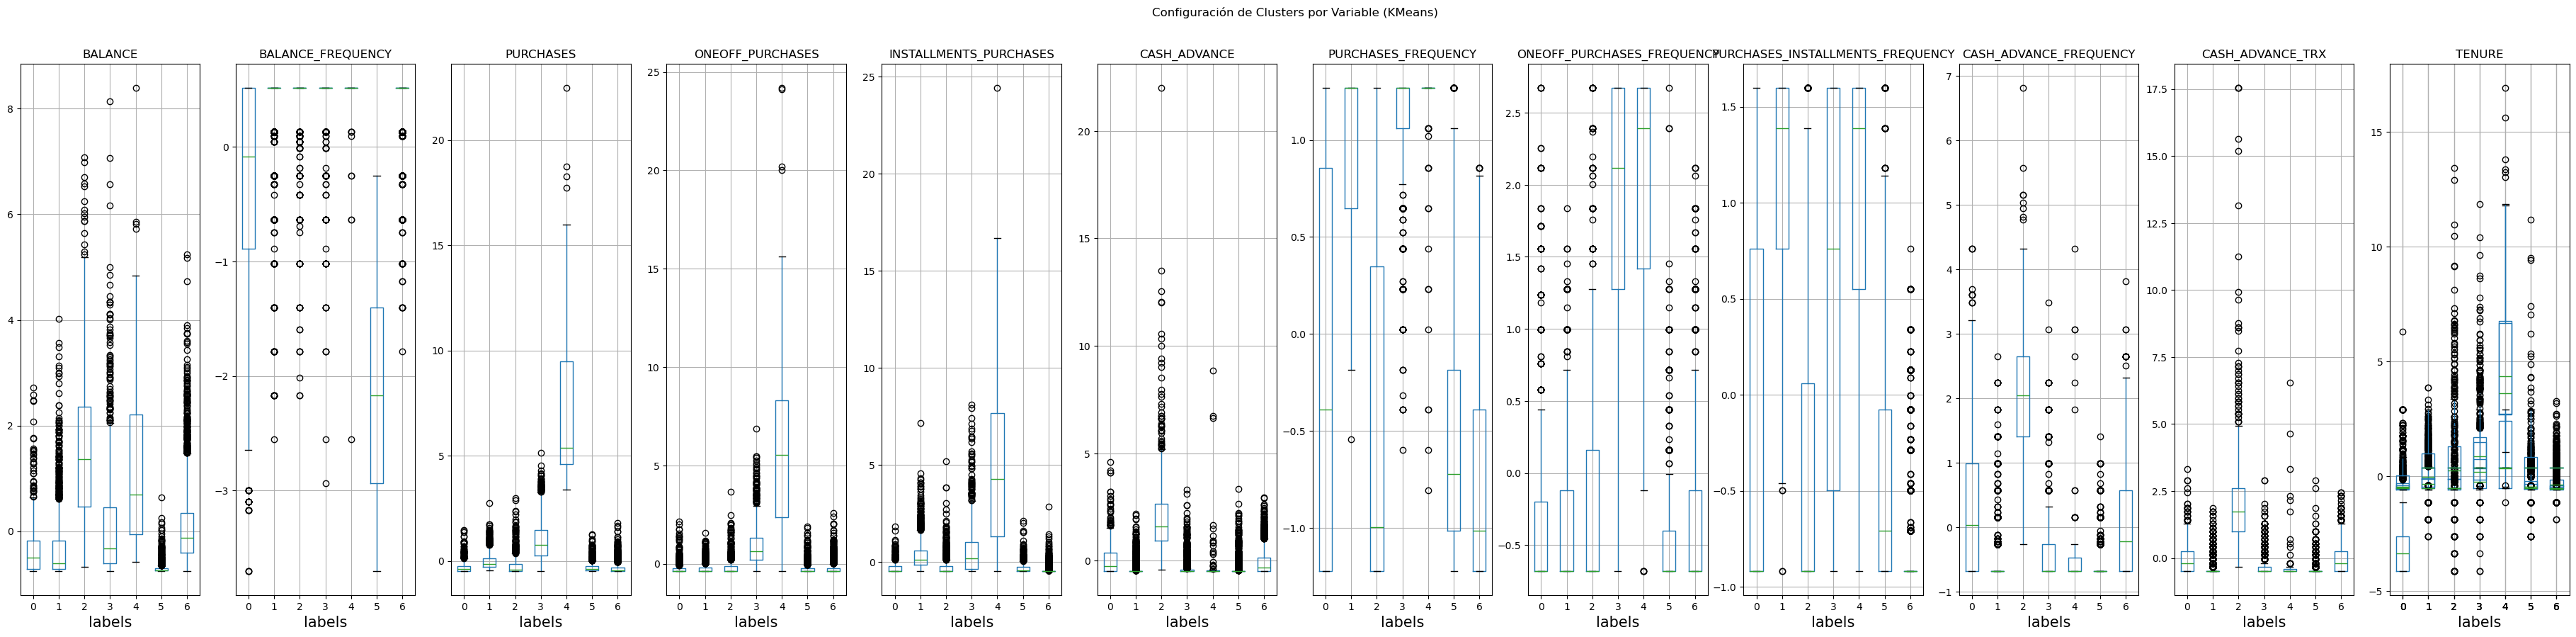

In [180]:
fig, ax = plt.subplots(1,12, figsize=(45,10))
df_labeled.boxplot('BALANCE','labels',ax=ax[0])
df_labeled.boxplot('BALANCE_FREQUENCY','labels',ax=ax[1])
df_labeled.boxplot('PURCHASES','labels',ax=ax[2])
df_labeled.boxplot('ONEOFF_PURCHASES','labels',ax=ax[3])
df_labeled.boxplot('INSTALLMENTS_PURCHASES','labels',ax=ax[4])
df_labeled.boxplot('CASH_ADVANCE','labels',ax=ax[5])
df_labeled.boxplot('PURCHASES_FREQUENCY','labels',ax=ax[6])
df_labeled.boxplot('ONEOFF_PURCHASES_FREQUENCY','labels',ax=ax[7])
df_labeled.boxplot('PURCHASES_INSTALLMENTS_FREQUENCY','labels',ax=ax[8])
df_labeled.boxplot('CASH_ADVANCE_FREQUENCY','labels',ax=ax[9])
df_labeled.boxplot('CASH_ADVANCE_TRX','labels',ax=ax[10])
df_labeled.boxplot('PURCHASES_TRX','labels',ax=ax[11])
df_labeled.boxplot('PAYMENTS','labels',ax=ax[11])
df_labeled.boxplot('PRC_FULL_PAYMENT','labels',ax=ax[11])
df_labeled.boxplot('TENURE','labels',ax=ax[11])
fig.suptitle('Configuración de Clusters por Variable (KMeans)')

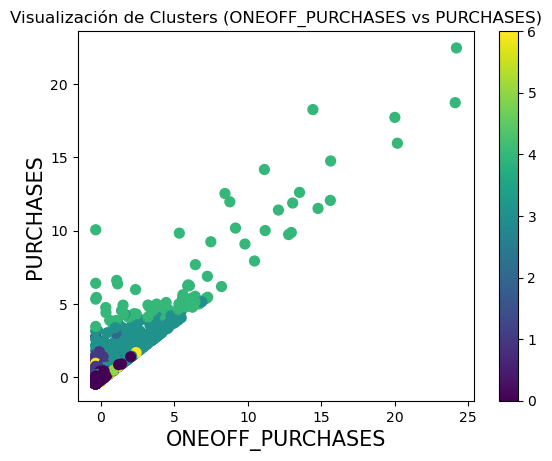

In [181]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['ONEOFF_PURCHASES'],df_labeled['PURCHASES'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (ONEOFF_PURCHASES vs PURCHASES)')
ax.set_xlabel('ONEOFF_PURCHASES')
ax.set_ylabel('PURCHASES')
plt.colorbar(scatter)

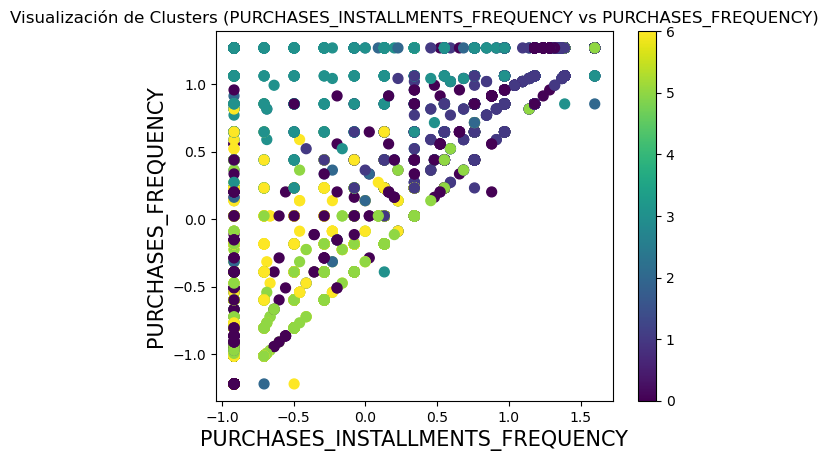

In [182]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PURCHASES_INSTALLMENTS_FREQUENCY'],df_labeled['PURCHASES_FREQUENCY'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PURCHASES_INSTALLMENTS_FREQUENCY vs PURCHASES_FREQUENCY)')
ax.set_xlabel('PURCHASES_INSTALLMENTS_FREQUENCY')
ax.set_ylabel('PURCHASES_FREQUENCY')
plt.colorbar(scatter)

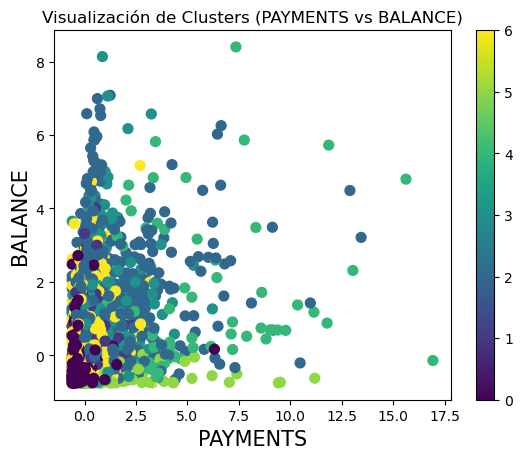

In [183]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PAYMENTS'],df_labeled['BALANCE'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PAYMENTS vs BALANCE)')
ax.set_xlabel('PAYMENTS')
ax.set_ylabel('BALANCE')
plt.colorbar(scatter)

# Hierarchical Clustering


In [184]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z =  linkage(df2, 'average',metric='euclidean')
Z.shape

(8949, 4)

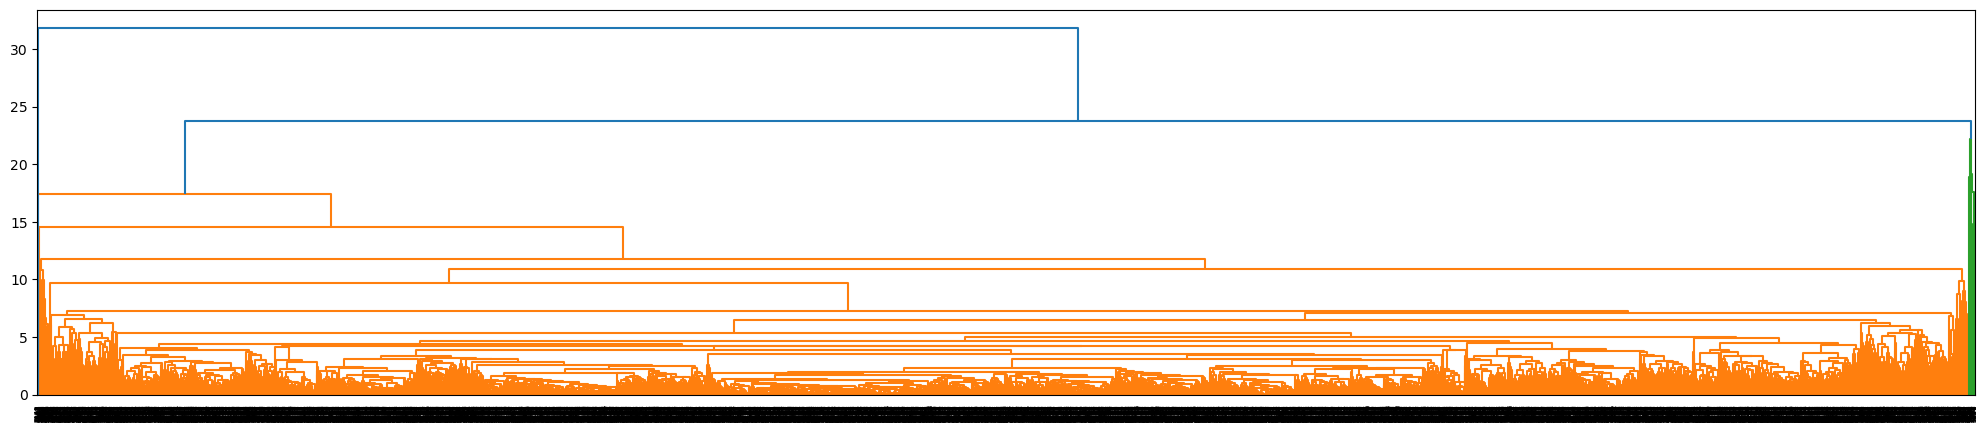

In [185]:
plt.figure(figsize=(25,5))
dendrogram(Z)
plt.show()

In [186]:
c, coph_dists = cophenet(Z,pdist(df2))
print('Cophenetic Coefficient:', format(c,'.4f'))

Cophenetic Coefficient: 0.8691


In [187]:
sil_df = pd.DataFrame({},columns=['Model','n_clusters','score'],index=None)

In [188]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for n_clusters in range(2, 10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init='auto')
    labels = clusterer.fit_predict(df2)

    score = silhouette_score(df2, labels)

    results.append({
        'Model': 'KMeans',
        'n_clusters': n_clusters,
        'score': score
    })

sil_df = pd.DataFrame(results)

Text(0.5, 1.0, 'Silhouette Score')

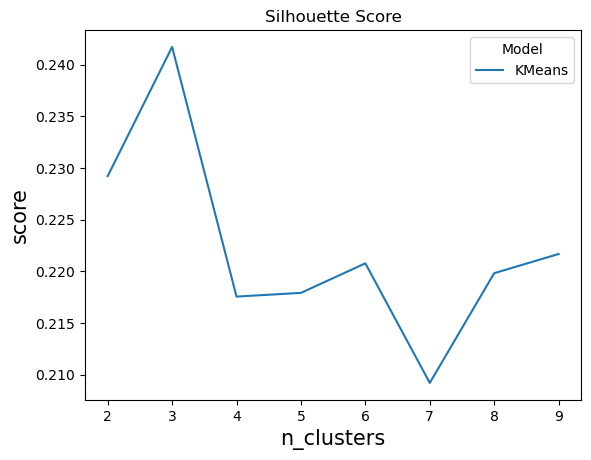

In [189]:
sns.lineplot(data = sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhouette Score')

### version 3 clusters


In [190]:
kmeans =  KMeans(n_clusters=3, n_init = 15, random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=3, n_init=15, random_state=1)

In [191]:
prediction

array([2, 4, 3, ..., 1, 2, 3], dtype=int32)

In [192]:
kmeans = KMeans(n_clusters=3,n_init=15,random_state=1)
kmeans.fit(df2)

KMeans(n_clusters=3, n_init=15, random_state=1)

In [193]:
centroids = kmeans.cluster_centers_
centroids

array([[ 0.18933173, -0.13214499, -0.35131331, -0.23586357, -0.39727717,
         0.29683957, -0.85458095, -0.39456237, -0.75523675,  0.42568278,
         0.30598849, -0.48103648, -0.06697155, -0.38890517, -0.09029642],
       [ 0.96585707,  0.46447561,  2.67220166,  2.29952662,  2.09368223,
         0.21454584,  1.14450436,  1.7309074 ,  1.09083665, -0.06250859,
         0.10979685,  2.71044204,  1.86723163,  0.33621283,  0.31689036],
       [-0.34582355,  0.08826308,  0.04136963, -0.04019566,  0.17158738,
        -0.36741584,  0.82080882,  0.21727283,  0.7147165 , -0.4771153 ,
        -0.36376535,  0.18418578, -0.17469857,  0.39836322,  0.06037748]])

In [194]:
centroid_df = pd.DataFrame(centroids,columns=list(df2))
centroid_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.19,-0.13,-0.35,-0.24,-0.40,0.30,-0.85,-0.39,-0.76,0.43,0.31,-0.48,-0.07,-0.39,-0.09
1,0.97,0.46,2.67,2.30,2.09,0.21,1.14,1.73,1.09,-0.06,0.11,2.71,1.87,0.34,0.32
2,-0.35,0.09,0.04,-0.04,0.17,-0.37,0.82,0.22,0.71,-0.48,-0.36,0.18,-0.17,0.40,0.06


In [195]:
df_labels = pd.DataFrame(kmeans.labels_,columns=list(['labels']))
df_labels['labels'] = df_labels['labels'].astype('category')

In [196]:
df_labeled = df2.join(df_labels)

In [197]:
df_labeled.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'labels'],
      dtype='object')

In [198]:
df_labeled.head(20)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,PAYMENTS,PRC_FULL_PAYMENT,TENURE,labels
0,-0.73,-0.25,-0.42,-0.36,-0.35,-0.47,-0.81,-0.68,-0.71,-0.68,-0.48,-0.51,-0.53,-0.53,0.36,0
1,0.79,0.13,-0.47,-0.36,-0.45,2.61,-1.22,-0.68,-0.92,0.57,0.11,-0.59,0.82,0.23,0.36,0
2,0.45,0.52,-0.11,0.11,-0.45,-0.47,1.27,2.67,-0.92,-0.68,-0.48,-0.11,-0.38,-0.53,0.36,2
3,0.05,-1.02,0.23,0.55,-0.45,-0.37,-1.01,-0.40,-0.92,-0.26,-0.33,-0.55,-0.60,-0.53,0.36,0
4,-0.36,0.52,-0.46,-0.35,-0.45,-0.47,-1.01,-0.40,-0.92,-0.68,-0.48,-0.55,-0.36,-0.53,0.36,0
5,0.12,0.52,0.15,-0.36,1.02,-0.47,0.44,-0.68,0.55,-0.68,-0.48,-0.27,-0.12,-0.53,0.36,2
6,-0.45,0.52,2.85,3.50,0.31,-0.47,1.27,2.67,1.60,-0.68,-0.48,1.98,1.60,2.89,0.36,1
7,0.12,0.52,-0.27,-0.36,0.03,-0.47,1.27,-0.68,1.60,-0.68,-0.48,-0.11,-0.36,-0.53,0.36,2
8,-0.26,0.52,-0.07,0.04,-0.23,-0.47,-0.39,-0.40,-0.29,-0.68,-0.48,-0.39,-0.36,-0.53,0.36,0
9,-0.68,-1.40,0.13,0.42,-0.45,-0.47,-0.81,-0.12,-0.92,-0.68,-0.48,-0.47,-0.20,-0.53,0.36,0


In [199]:
df_labeled['labels'].value_counts()

labels
0    4489
2    3933
1     528
Name: count, dtype: int64

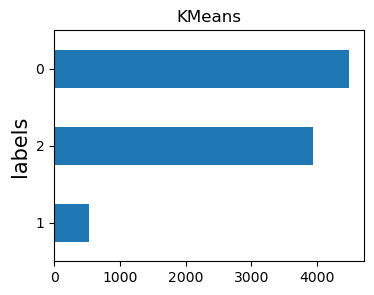

In [200]:
fig, ax = plt.subplots(figsize=(4,3))

pd.value_counts(df_labeled['labels']) \
    .sort_values(ascending=True) \
    .plot(kind='barh', ax=ax)

ax.set_title('KMeans')
plt.show()

In [201]:
df2.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

Text(0.5, 0.98, 'Configuración de Clusters por Variable (KMeans)')

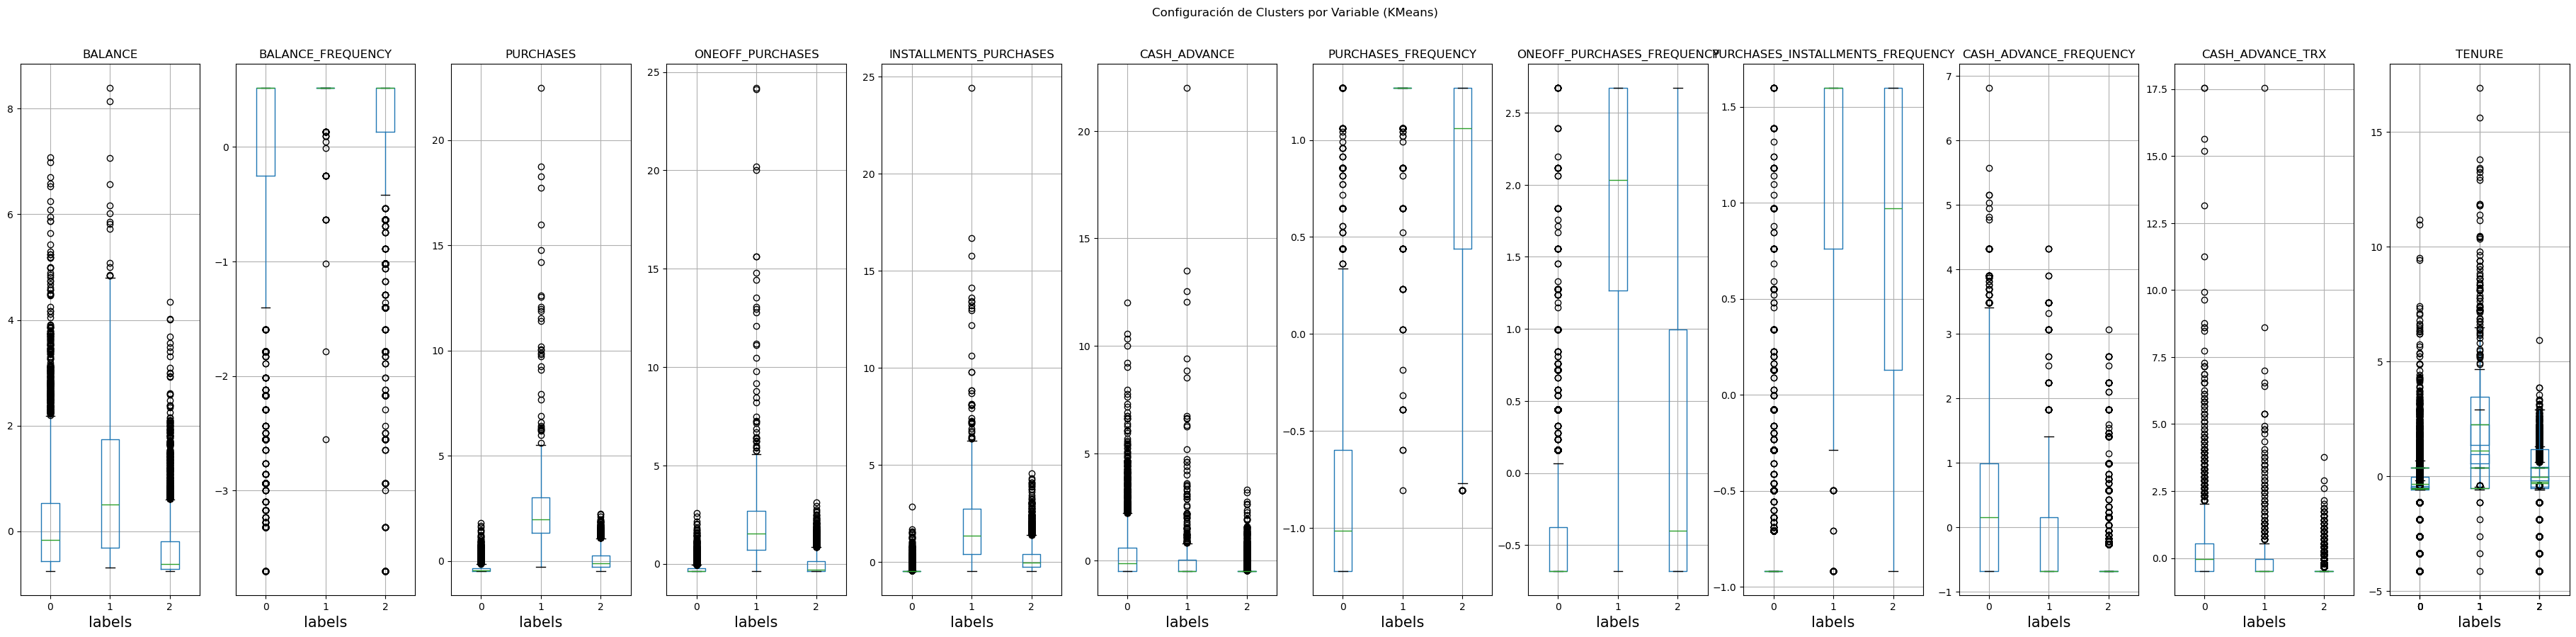

In [202]:
fig, ax = plt.subplots(1,12, figsize=(45,10))
df_labeled.boxplot('BALANCE','labels',ax=ax[0])
df_labeled.boxplot('BALANCE_FREQUENCY','labels',ax=ax[1])
df_labeled.boxplot('PURCHASES','labels',ax=ax[2])
df_labeled.boxplot('ONEOFF_PURCHASES','labels',ax=ax[3])
df_labeled.boxplot('INSTALLMENTS_PURCHASES','labels',ax=ax[4])
df_labeled.boxplot('CASH_ADVANCE','labels',ax=ax[5])
df_labeled.boxplot('PURCHASES_FREQUENCY','labels',ax=ax[6])
df_labeled.boxplot('ONEOFF_PURCHASES_FREQUENCY','labels',ax=ax[7])
df_labeled.boxplot('PURCHASES_INSTALLMENTS_FREQUENCY','labels',ax=ax[8])
df_labeled.boxplot('CASH_ADVANCE_FREQUENCY','labels',ax=ax[9])
df_labeled.boxplot('CASH_ADVANCE_TRX','labels',ax=ax[10])
df_labeled.boxplot('PURCHASES_TRX','labels',ax=ax[11])
df_labeled.boxplot('PAYMENTS','labels',ax=ax[11])
df_labeled.boxplot('PRC_FULL_PAYMENT','labels',ax=ax[11])
df_labeled.boxplot('TENURE','labels',ax=ax[11])
fig.suptitle('Configuración de Clusters por Variable (KMeans)')


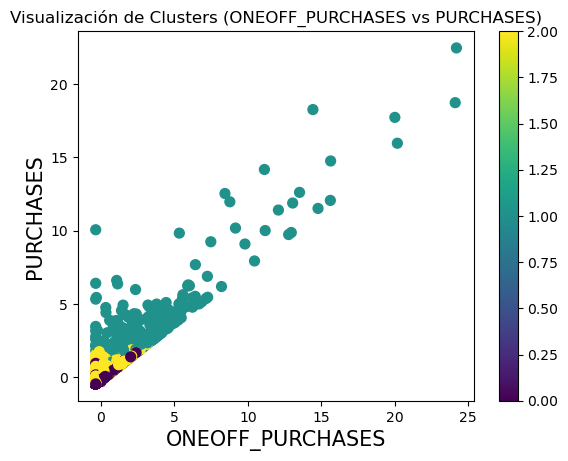

In [203]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['ONEOFF_PURCHASES'],df_labeled['PURCHASES'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (ONEOFF_PURCHASES vs PURCHASES)')
ax.set_xlabel('ONEOFF_PURCHASES')
ax.set_ylabel('PURCHASES')
plt.colorbar(scatter)

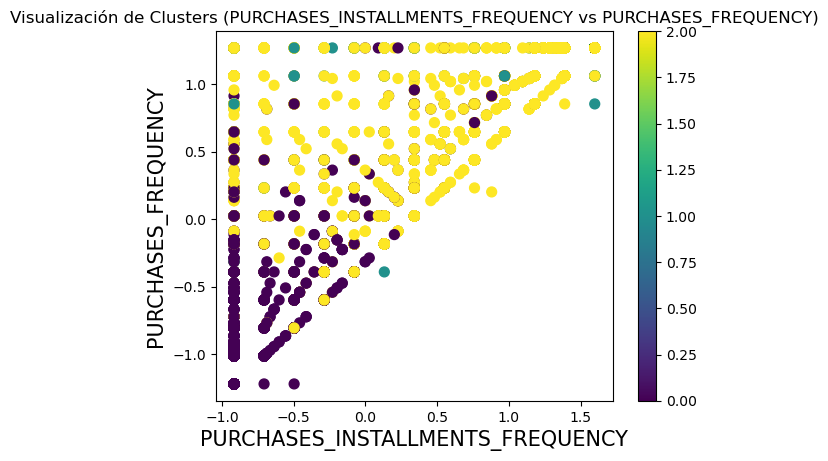

In [204]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PURCHASES_INSTALLMENTS_FREQUENCY'],df_labeled['PURCHASES_FREQUENCY'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PURCHASES_INSTALLMENTS_FREQUENCY vs PURCHASES_FREQUENCY)')
ax.set_xlabel('PURCHASES_INSTALLMENTS_FREQUENCY')
ax.set_ylabel('PURCHASES_FREQUENCY')
plt.colorbar(scatter)

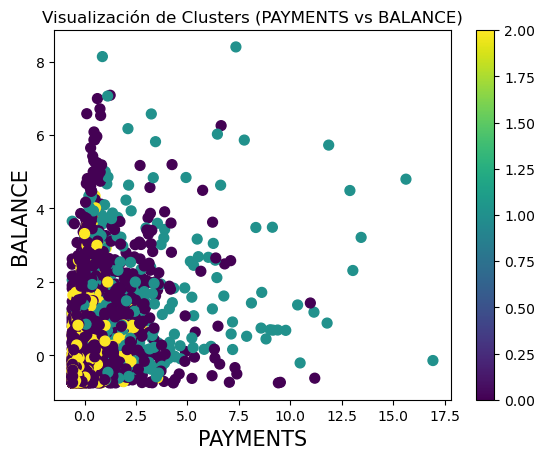

In [205]:
fig = plt.figure()
ax = fig.add_subplot(111)
scatter = ax.scatter(df_labeled['PAYMENTS'],df_labeled['BALANCE'],c=df_labeled['labels'],s=50)
ax.set_title('Visualización de Clusters (PAYMENTS vs BALANCE)')
ax.set_xlabel('PAYMENTS')
ax.set_ylabel('BALANCE')
plt.colorbar(scatter)


In [206]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z =  linkage(df2, 'average',metric='euclidean')
Z.shape

(8949, 4)

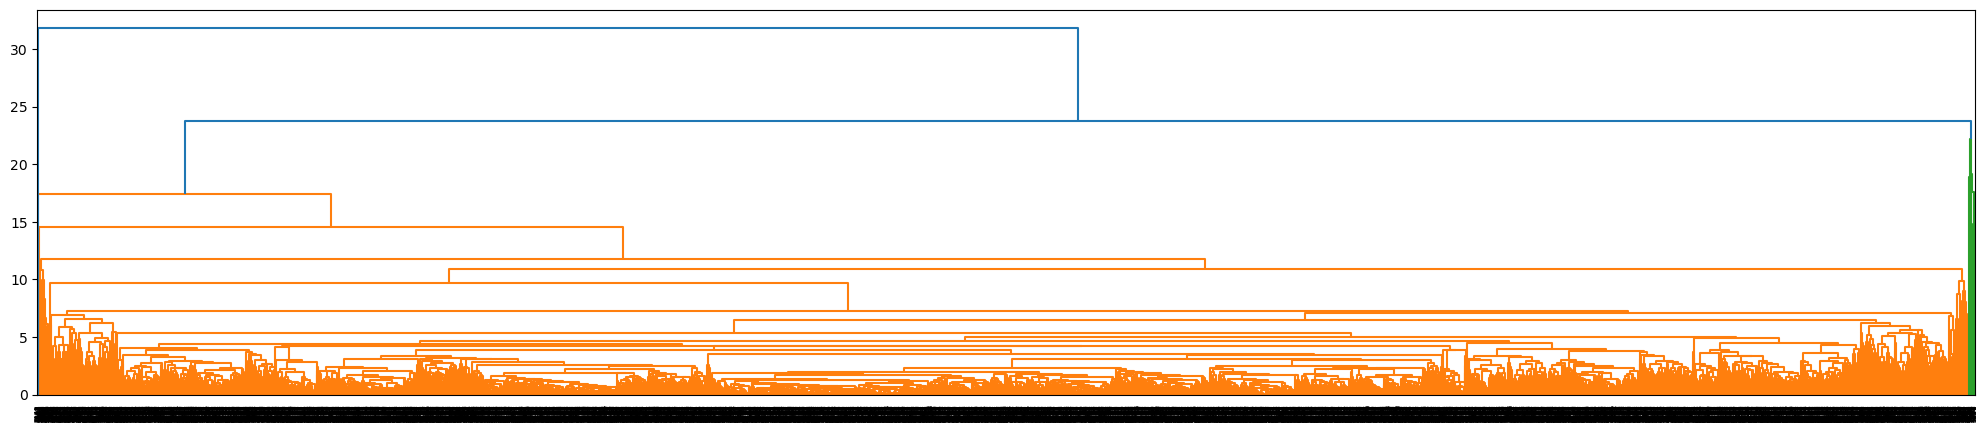

In [207]:
plt.figure(figsize=(25,5))
dendrogram(Z)
plt.show()

In [208]:
c, coph_dists = cophenet(Z,pdist(df2))
print('Cophenetic Coefficient:', format(c,'.4f'))

Cophenetic Coefficient: 0.8691


In [209]:
sil_df = pd.DataFrame({},columns=['Model','n_clusters','score'],index=None)

In [210]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for n_clusters in range(2, 10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=1, n_init='auto')
    labels = clusterer.fit_predict(df2)

    score = silhouette_score(df2, labels)

    results.append({
        'Model': 'KMeans',
        'n_clusters': n_clusters,
        'score': score
    })

sil_df = pd.DataFrame(results)

Text(0.5, 1.0, 'Silhouette Score')

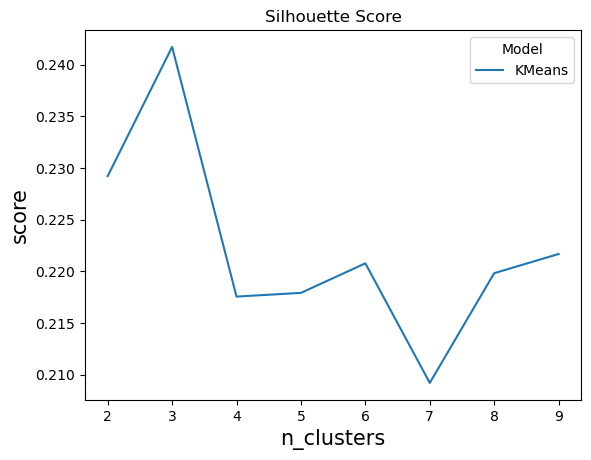

In [211]:
sns.lineplot(data = sil_df, x='n_clusters', y='score', hue='Model', style='Model', ci=None).set_title('Silhouette Score')